# Phase 1: Data Understanding

Goal:
- Load the credit default dataset
- Understand the target variable
- Inspect feature types and quality
- Identify initial patterns relevant to default risk

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
df = pd.read_excel("/Users/jacobcheng/Projects/credit_risk_project/data/raw/credit_card_clients_raw.xls", header=1)
df.shape

(30000, 25)

In [34]:
df.head(10)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
5,6,50000,1,1,2,37,0,0,0,0,...,19394,19619,20024,2500,1815,657,1000,1000,800,0
6,7,500000,1,1,2,29,0,0,0,0,...,542653,483003,473944,55000,40000,38000,20239,13750,13770,0
7,8,100000,2,2,2,23,0,-1,-1,0,...,221,-159,567,380,601,0,581,1687,1542,0
8,9,140000,2,3,1,28,0,0,2,0,...,12211,11793,3719,3329,0,432,1000,1000,1000,0
9,10,20000,1,3,2,35,-2,-2,-2,-2,...,0,13007,13912,0,0,0,13007,1122,0,0


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_AMT3        

## Column Descriptions

- **ID**: Unique identifier for each customer (not a predictive feature)

### Customer Characteristics
- **LIMIT_BAL**: Amount of given credit (credit limit)
- **SEX**: Gender (coded)
- **EDUCATION**: Education level (coded)
- **MARRIAGE**: Marital status (coded)
- **AGE**: Age of the customer

### Repayment Status (Recent History)
- **PAY_0**: Repayment status in the most recent month
- **PAY_2 – PAY_6**: Repayment status in previous months  
  (Values typically represent delay in payment; higher values indicate worse repayment behavior)

### Bill Statement Amounts
- **BILL_AMT1 – BILL_AMT6**: Amount of bill statements for the past 6 months

### Payment Amounts
- **PAY_AMT1 – PAY_AMT6**: Amount of previous payments made in the past 6 months

### Target Variable
- **default payment next month**:  
  - 1 = customer will default next month  
  - 0 = customer will not default

Observations:
- All the variables are numeric.
- ID is an identifier, not a predictive feature.
- SEX, EDUCATION, and MARRIAGE appear to be coded categorical variables.
- PAY variables look ordinal because they represent repayment status levels.
- No missing values were detected in the raw dataset. However, invalid coded values may still need cleaning.

In [ ]:
df.duplicated().sum()
df["ID"].duplicated().sum()

np.int64(0)

This dataset has no fully duplicated rows. Customer IDs should stillbe checked as duplicate IDs can mean repeated information.

In [33]:
target_col = "default payment next month"
df[target_col].head()

0    1
1    1
2    0
3    0
4    0
Name: default payment next month, dtype: int64

In [38]:
df[target_col].unique()

array([1, 0])

In [37]:
df[target_col].value_counts()

default payment next month
0    23364
1     6636
Name: count, dtype: int64

In [39]:
df[target_col].value_counts(normalize=True)

default payment next month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

Target variable is binary:
 - 0 = no default next month
 - 1 = default next month

There are more non-defaults than defaults. This means accuracy will not be a reliable performance metric later.

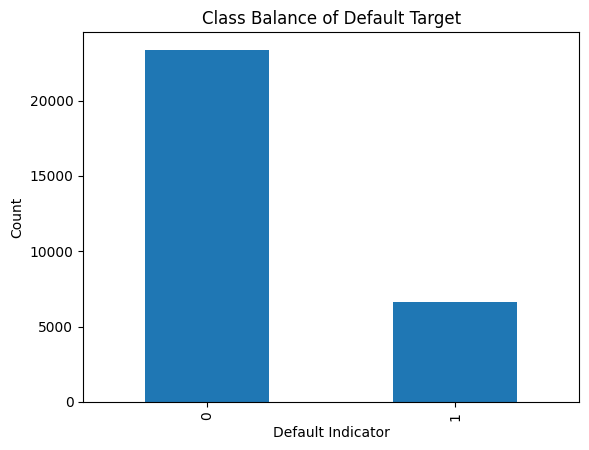

In [40]:
df[target_col].value_counts().plot(kind="bar")
plt.title("Class Balance of Default Target")
plt.xlabel("Default Indicator")
plt.ylabel("Count")
plt.show()

In [41]:
id_col = "ID"
categorical_cols = ["SEX", "EDUCATION", "MARRIAGE"]
ordinal_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
numeric_cols = [
    "LIMIT_BAL", "AGE",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

In [43]:
print("Categorical columns:", categorical_cols)
print("Ordinal columns:", ordinal_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['SEX', 'EDUCATION', 'MARRIAGE']
Ordinal columns: ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
Numeric columns: ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


In [44]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts().sort_index())


SEX
SEX
1    11888
2    18112
Name: count, dtype: int64

EDUCATION
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


In [45]:
for col in ordinal_cols:
    print(f"\n{col}")
    print(df[col].value_counts().sort_index())


PAY_0
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

PAY_2
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

PAY_3
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

PAY_4
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

PAY_5
PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

PAY_6
PAY_6
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19
 7       46
 8        2
Name: count, dtype: int6

Some categorical variables use integer codes rather than descriptive labels. These will need documentation and possibly remapping in the cleaning phase. Repayment status variables appear ordinal and are likely among the most important predictors of default.

In [46]:
df["LIMIT_BAL"].describe()

count      30000.000000
mean      167484.322667
std       129747.661567
min        10000.000000
25%        50000.000000
50%       140000.000000
75%       240000.000000
max      1000000.000000
Name: LIMIT_BAL, dtype: float64

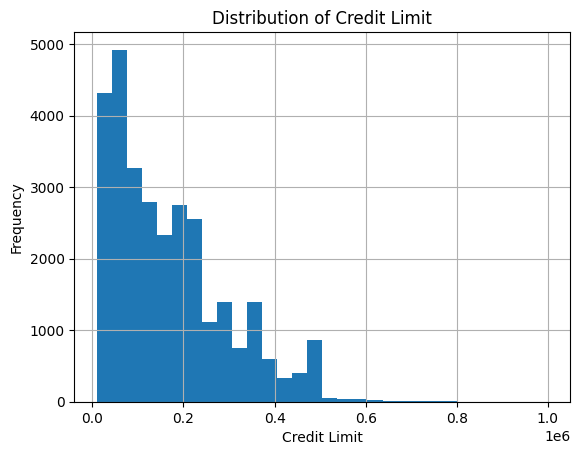

In [47]:
df["LIMIT_BAL"].hist(bins=30)
plt.title("Distribution of Credit Limit")
plt.xlabel("Credit Limit")
plt.ylabel("Frequency")
plt.show()

In [48]:
df["AGE"].describe()

count    30000.000000
mean        35.485500
std          9.217904
min         21.000000
25%         28.000000
50%         34.000000
75%         41.000000
max         79.000000
Name: AGE, dtype: float64

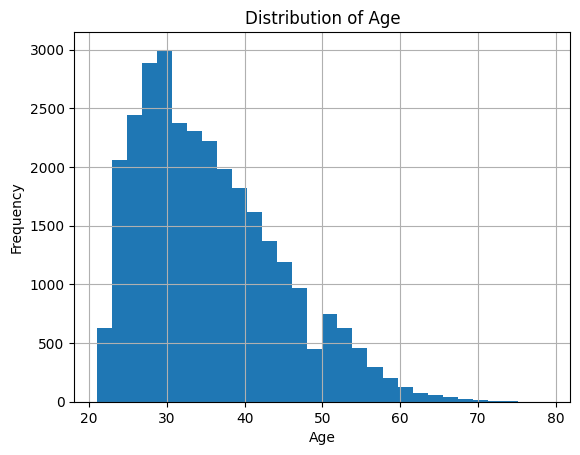

In [49]:
df["AGE"].hist(bins=30)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

In [50]:
df["BILL_AMT1"].describe()

count     30000.000000
mean      51223.330900
std       73635.860576
min     -165580.000000
25%        3558.750000
50%       22381.500000
75%       67091.000000
max      964511.000000
Name: BILL_AMT1, dtype: float64

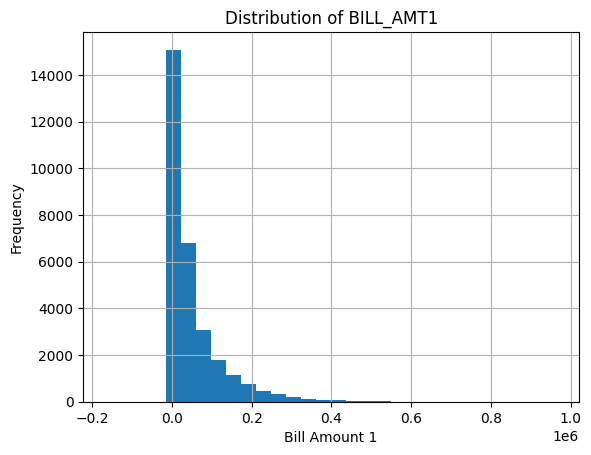

In [51]:
df["BILL_AMT1"].hist(bins=30)
plt.title("Distribution of BILL_AMT1")
plt.xlabel("Bill Amount 1")
plt.ylabel("Frequency")
plt.show()

In [52]:
df["PAY_AMT1"].describe()

count     30000.000000
mean       5663.580500
std       16563.280354
min           0.000000
25%        1000.000000
50%        2100.000000
75%        5006.000000
max      873552.000000
Name: PAY_AMT1, dtype: float64

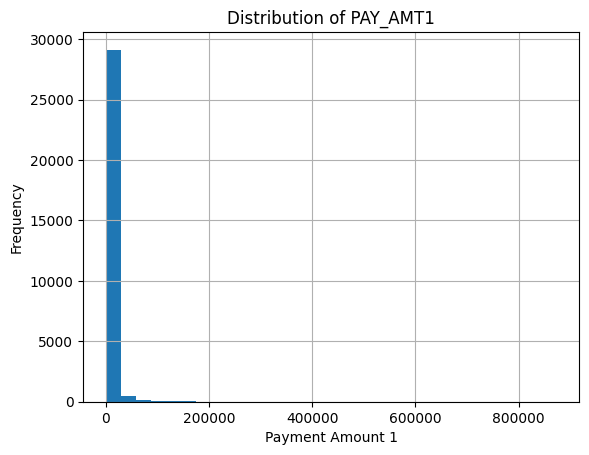

In [53]:
df["PAY_AMT1"].hist(bins=30)
plt.title("Distribution of PAY_AMT1")
plt.xlabel("Payment Amount 1")
plt.ylabel("Frequency")
plt.show()

In [54]:
df.groupby("SEX")[target_col].mean()

SEX
1    0.241672
2    0.207763
Name: default payment next month, dtype: float64

In [55]:
df.groupby("MARRIAGE")[target_col].mean()

MARRIAGE
0    0.092593
1    0.234717
2    0.209283
3    0.260062
Name: default payment next month, dtype: float64

In [56]:
df.groupby("EDUCATION")[target_col].mean()

EDUCATION
0    0.000000
1    0.192348
2    0.237349
3    0.251576
4    0.056911
5    0.064286
6    0.156863
Name: default payment next month, dtype: float64

In [57]:
df.groupby("PAY_0")[target_col].mean()

PAY_0
-2    0.132294
-1    0.167781
 0    0.128113
 1    0.339479
 2    0.691414
 3    0.757764
 4    0.684211
 5    0.500000
 6    0.545455
 7    0.777778
 8    0.578947
Name: default payment next month, dtype: float64

## Initial Findings

- The dataset contains 30,000 observations and a binary default target.
- The target is imbalanced, with non-defaults outnumbering defaults.
- Most features are numeric, but several are integer-coded categorical or ordinal variables.
- Repayment status variables appear strongly related to default risk and are likely to be important predictors.
- Financial amount variables such as bill and payment amounts are heavily skewed and may require transformation or careful treatment later.
- ID should be removed before modeling because it is only an identifier.